# Week 10 — Lecture 16: Object Detection

Build the detector family in historical order and make the computational change at each step visible.


## From classification to detection

A classifier answers *what is in this crop?* A detector must also decide *where to look*. We begin with the classic recipe from the lecture notes: build an image pyramid, move a fixed-size window across every scale, classify every crop with a pretrained CNN, and remove duplicate detections. Then we keep the same pretrained ResNet-18 backbone while changing how proposals are generated and how convolution is shared:

1. **Sliding-window detector:** systematic windows over an image pyramid.
2. **R-CNN:** fewer, object-like region proposals; one backbone pass per crop.
3. **Fast R-CNN:** one shared feature map; ROI Align extracts every proposal.
4. **Faster R-CNN:** a learned region proposal network; optional training comes last.


## Setup

Every detector below uses the same torchvision `ResNet18_Weights.DEFAULT` backbone.


In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import torch
from ipywidgets import FloatSlider, IntSlider, interact
from matplotlib.patches import Rectangle
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import VOCDetection
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign, box_iou, nms, roi_align
from torchvision.transforms.functional import pil_to_tensor, resize
from torchvision.utils import draw_bounding_boxes

# Reproducible sampling makes lecture results easier to compare between runs.
torch.manual_seed(7)
random.seed(7)

# Keep device selection in one place so every model and tensor follows the same policy.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIRECTORY = Path("../../datasets").resolve()
PRETRAINED_WEIGHTS = ResNet18_Weights.DEFAULT

# These limits keep a full top-to-bottom lecture run practical while using real VOC data.
RCNN_TRAIN_IMAGES = 1_000
FAST_RCNN_TRAIN_IMAGES = 1_000
FASTER_RCNN_TRAIN_IMAGES = 1_000

print(f"Device: {DEVICE}")
print(f"Dataset: {DATA_DIRECTORY}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")


Device: cuda
Dataset: /home/rwhite/Documents/datasets
GPU: NVIDIA GeForce RTX 5090


## Pascal VOC 2007

VOC is far smaller than COCO but is not a toy or synthetic dataset. It contains varied natural images, multiple objects per image, and 20 familiar classes. `torchvision` downloads the official train/validation split and parses its XML annotations. We use a reproducible subset by default so the entire notebook is practical during class; increase `TRAIN_IMAGE_LIMIT` for a longer run.

In [2]:
# Detection models reserve class 0 for background; the 20 VOC classes begin at index 1.
VOC_CLASSES = [
    "__background__", "aeroplane", "bicycle", "bird", "boat",
    "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
    "dog", "horse", "motorbike", "person", "pottedplant", "sheep",
    "sofa", "train", "tvmonitor",
]
CLASS_TO_INDEX = {name: index for index, name in enumerate(VOC_CLASSES)}

# Both splits share the extracted VOCdevkit directory under ../../datasets.
voc_train = VOCDetection(
    root=DATA_DIRECTORY, year="2007", image_set="train", download=True
)
voc_validation = VOCDetection(
    root=DATA_DIRECTORY, year="2007", image_set="val", download=True
)

def unpack_target(annotation):
    # torchvision returns the original XML structure as nested dictionaries.
    objects = annotation["annotation"].get("object", [])
    # A one-object image produces a dict; multi-object images produce a list.
    if isinstance(objects, dict):
        objects = [objects]

    boxes, labels = [], []
    for object_annotation in objects:
        box = object_annotation["bndbox"]
        boxes.append([float(box[key]) for key in ("xmin", "ymin", "xmax", "ymax")])
        labels.append(CLASS_TO_INDEX[object_annotation["name"]])
    # Faster R-CNN expects float XYXY boxes and integer class indices.
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels)

print(f"Training images: {len(voc_train):,}")
print(f"Validation images: {len(voc_validation):,}")


Training images: 2,501
Validation images: 2,510


In [3]:
def show_voc_image(index=0):
    image, annotation = voc_train[index]
    boxes, labels = unpack_target(annotation)
    # draw_bounding_boxes expects the original uint8 CHW representation.
    image_tensor = pil_to_tensor(image)
    label_names = [VOC_CLASSES[label] for label in labels]
    drawn = draw_bounding_boxes(image_tensor, boxes, labels=label_names, width=3)

    plt.figure(figsize=(10, 7))
    plt.imshow(drawn.permute(1, 2, 0))
    plt.axis("off")
    plt.show()

# continuous_update=False redraws only after the slider is released.
interact(
    show_voc_image,
    index=IntSlider(min=0, max=min(100, len(voc_train) - 1), step=1, value=0, continuous_update=False),
);


interactive(children=(IntSlider(value=0, continuous_update=False, description='index'), Output()), _dom_classe…

# Classic detector: image pyramid + moving window

The window is fixed in the resized image, but the pyramid makes it cover objects at several scales in the original image. This is deliberately inefficient: seeing the redundant crops makes the motivation for R-CNN and Fast R-CNN concrete.

The pretrained ResNet-18 head still predicts **ImageNet** classes here. That gives us a working generic detector before any VOC training. In the R-CNN section we replace only its final classifier with a VOC-specific head.


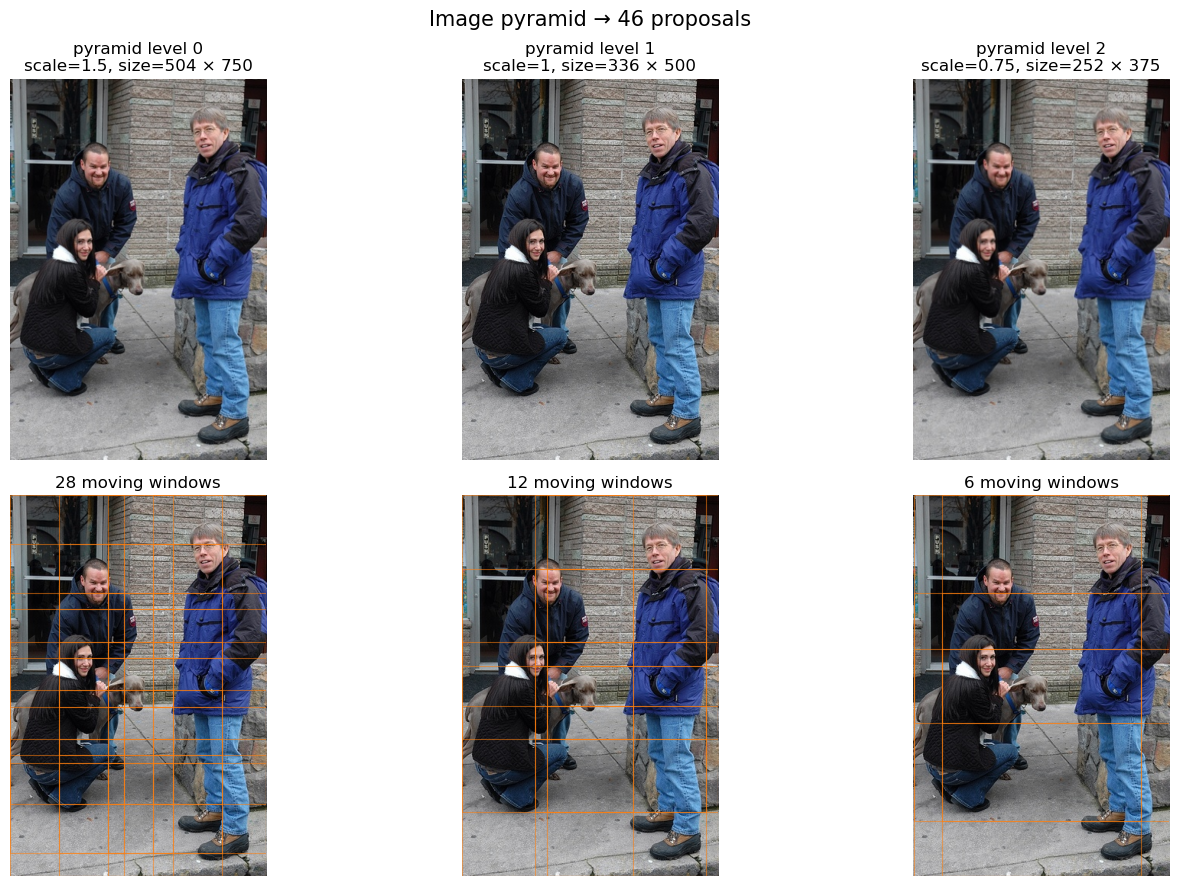

interactive(children=(IntSlider(value=6, continuous_update=False, description='index', max=40), IntSlider(valu…

In [4]:
def build_image_pyramid(image, scales=(1.5, 1.0, 0.75)):
    """Resize one image uniformly to several scales without changing its aspect ratio."""
    # Convert the PIL image into CHW floating-point pixels in [0, 1].
    original = pil_to_tensor(image).float() / 255
    height, width = original.shape[-2:]
    pyramid = []

    # Enlarged levels make small objects fill a 224-pixel window; reduced levels do
    # the same for larger objects. This is how a fixed window becomes scale-aware.
    for scale in scales:
        level_size = [round(height * scale), round(width * scale)]
        if min(level_size) < 224:
            continue
        pyramid.append((scale, resize(original, level_size, antialias=True)))

    # A few VOC images are very narrow. Guarantee that even those images have one
    # level large enough to accept the fixed 224 × 224 classification window.
    if not pyramid:
        fallback_scale = 224 / min(height, width)
        fallback_size = [round(height * fallback_scale), round(width * fallback_scale)]
        pyramid.append((fallback_scale, resize(original, fallback_size, antialias=True)))
    return pyramid


def moving_window_proposals(pyramid, window_size=224, stride=96):
    """Return each crop and its XYXY box mapped onto the original image."""
    proposals = []
    for level_index, (scale, level) in enumerate(pyramid):
        height, width = level.shape[-2:]

        # Build a regular grid at this level. A smaller stride yields more overlap,
        # better spatial coverage, and much more repeated CNN computation.
        x_starts = list(range(0, max(1, width - window_size + 1), stride))
        y_starts = list(range(0, max(1, height - window_size + 1), stride))

        # Force one final window against the right and bottom borders so no strip of
        # the image is missed merely because the stride did not divide evenly.
        if not x_starts or x_starts[-1] != width - window_size:
            x_starts.append(max(0, width - window_size))
        if not y_starts or y_starts[-1] != height - window_size:
            y_starts.append(max(0, height - window_size))

        for y_min in y_starts:
            for x_min in x_starts:
                crop = level[:, y_min:y_min + window_size, x_min:x_min + window_size]

                # Coordinates above live in the resized pyramid level. Dividing by
                # scale maps the rectangle back onto the original VOC image.
                box = torch.tensor([
                    x_min / scale, y_min / scale,
                    (x_min + window_size) / scale, (y_min + window_size) / scale,
                ], dtype=torch.float32)
                proposals.append({"level": level_index, "scale": scale, "box": box, "crop": crop})
    return proposals


def show_pyramid_and_windows(index=6, stride=96):
    image, _ = voc_validation[index]
    pyramid = build_image_pyramid(image)
    proposals = moving_window_proposals(pyramid, stride=stride)
    figure, axes = plt.subplots(2, len(pyramid), figsize=(15, 9), squeeze=False)

    # Top row: pixels actually seen at each scale. Bottom row: every fixed window
    # projected back onto the original image coordinate system.
    for level_index, (scale, level) in enumerate(pyramid):
        axes[0, level_index].imshow(level.permute(1, 2, 0))
        axes[0, level_index].set_title(
            f"pyramid level {level_index}\nscale={scale:g}, size={level.shape[-1]} × {level.shape[-2]}"
        )
        axes[0, level_index].axis("off")

        axes[1, level_index].imshow(image)
        level_proposals = [proposal for proposal in proposals if proposal["level"] == level_index]
        for proposal in level_proposals:
            x_min, y_min, x_max, y_max = proposal["box"].tolist()
            axes[1, level_index].add_patch(Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                fill=False, edgecolor="tab:orange", linewidth=0.8, alpha=0.55,
            ))
        axes[1, level_index].set_title(f"{len(level_proposals)} moving windows")
        axes[1, level_index].axis("off")

    figure.suptitle(f"Image pyramid → {len(proposals)} proposals", fontsize=15)
    plt.tight_layout()
    plt.show()


classic_image, _ = voc_validation[6]
classic_pyramid = build_image_pyramid(classic_image)
classic_proposals = moving_window_proposals(classic_pyramid)
show_pyramid_and_windows()
interact(
    show_pyramid_and_windows,
    index=IntSlider(min=0, max=40, value=6, continuous_update=False),
    stride=IntSlider(min=64, max=160, step=16, value=96, continuous_update=False),
);


## Classify every window with the pretrained backbone

Each crop is normalized exactly as ResNet-18 expects. The model runs in batches and under `inference_mode`, but it still repeats almost the same convolution for heavily overlapping crops. The plots expose both the raw score field and the effect of non-maximum suppression.


In [5]:
# The untouched pretrained head predicts the 1,000 ImageNet categories.
classic_classifier = resnet18(weights=PRETRAINED_WEIGHTS).to(DEVICE).eval()
IMAGENET_CATEGORIES = PRETRAINED_WEIGHTS.meta["categories"]


@torch.inference_mode()
def classify_windows(proposals, batch_size=64):
    # Use the resize and normalization recipe paired with the downloaded weights.
    prepared = [PRETRAINED_WEIGHTS.transforms()(proposal["crop"]) for proposal in proposals]
    probabilities = []

    # Batching improves GPU utilization, although the backbone still processes each
    # overlapping crop independently—the classic detector's central inefficiency.
    for start in range(0, len(prepared), batch_size):
        batch = torch.stack(prepared[start:start + batch_size]).to(DEVICE)
        probabilities.append(classic_classifier(batch).softmax(dim=1).cpu())
    probabilities = torch.cat(probabilities)
    return probabilities.max(dim=1)  # (best score, best ImageNet class) per window


def classic_detector_outputs(index=6):
    image, _ = voc_validation[index]
    pyramid = build_image_pyramid(image)
    proposals = moving_window_proposals(pyramid)
    scores, labels = classify_windows(proposals)
    boxes = torch.stack([proposal["box"] for proposal in proposals])
    return image, proposals, boxes, scores, labels


def class_aware_nms(boxes, scores, labels, score_threshold, nms_threshold):
    # Threshold first so NMS does not waste effort comparing low-confidence windows.
    candidates = (scores >= score_threshold).nonzero().flatten()
    kept_by_class = []

    # Boxes predicting different classes must not suppress one another.
    for label in labels[candidates].unique():
        class_indices = candidates[labels[candidates] == label]
        local_keep = nms(boxes[class_indices], scores[class_indices], nms_threshold)
        kept_by_class.append(class_indices[local_keep])
    if not kept_by_class:
        return torch.empty(0, dtype=torch.long)
    kept = torch.cat(kept_by_class)
    return kept[scores[kept].argsort(descending=True)]


def show_classic_detector(index=6, score_threshold=0.20, nms_threshold=0.35):
    image, proposals, boxes, scores, labels = classic_detector_outputs(index)
    candidates = (scores >= score_threshold).nonzero().flatten()
    kept = class_aware_nms(boxes, scores, labels, score_threshold, nms_threshold)[:12]

    figure, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Stage 1: the detector has only geometry—no scores have been consulted yet.
    axes[0].imshow(image)
    for box in boxes:
        x_min, y_min, x_max, y_max = box.tolist()
        axes[0].add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                    fill=False, edgecolor="tab:orange", linewidth=0.5, alpha=0.25))
    axes[0].set_title(f"1. Pyramid proposals ({len(boxes)})")

    # Stage 2: plot confidence at each window center to reveal the dense score field.
    axes[1].imshow(image)
    centers_x = (boxes[:, 0] + boxes[:, 2]) / 2
    centers_y = (boxes[:, 1] + boxes[:, 3]) / 2
    score_plot = axes[1].scatter(centers_x, centers_y, c=scores, cmap="magma", s=45, vmin=0, vmax=1)
    figure.colorbar(score_plot, ax=axes[1], fraction=0.046, label="top ImageNet probability")
    axes[1].set_title(f"2. Score + threshold ({len(candidates)} remain)")

    # Stage 3: NMS retains only the strongest member of each overlapping cluster.
    axes[2].imshow(image)
    for detection_index in kept.tolist():
        x_min, y_min, x_max, y_max = boxes[detection_index].tolist()
        axes[2].add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                    fill=False, edgecolor="lime", linewidth=2))
        axes[2].text(x_min, y_min, f"{IMAGENET_CATEGORIES[labels[detection_index]]} {scores[detection_index]:.2f}",
                     fontsize=8, color="black", bbox={"facecolor": "lime", "alpha": 0.75, "pad": 1})
    axes[2].set_title(f"3. Class-aware NMS ({len(kept)} shown)")

    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()

    # Raw, unnormalized crops show exactly what produced the highest scores.
    top_indices = scores.argsort(descending=True)[:8]
    figure, axes = plt.subplots(2, 4, figsize=(12, 6))
    for axis, proposal_index in zip(axes.flat, top_indices.tolist()):
        axis.imshow(proposals[proposal_index]["crop"].permute(1, 2, 0).clamp(0, 1))
        axis.set_title(f"{IMAGENET_CATEGORIES[labels[proposal_index]]}\nscore={scores[proposal_index]:.2f}")
        axis.axis("off")
    figure.suptitle("Highest-scoring raw windows")
    plt.tight_layout()
    plt.show()


interact(
    show_classic_detector,
    index=IntSlider(min=0, max=40, value=6, continuous_update=False),
    score_threshold=FloatSlider(min=0.05, max=0.9, step=0.05, value=0.20, continuous_update=False),
    nms_threshold=FloatSlider(min=0.1, max=0.9, step=0.05, value=0.35, continuous_update=False),
);


interactive(children=(IntSlider(value=6, continuous_update=False, description='index', max=40), FloatSlider(va…

## NMS as its own component

The left panel shows all high-scoring windows before suppression. The middle panel draws a line from each removed box to the stronger box that replaces it conceptually. The right panel shows the final class-aware NMS output. Adjusting the IoU threshold makes the duplicate-removal rule visible independently of the other detector stages.


In [6]:
def show_nms_component(index=6, score_threshold=0.15, nms_threshold=0.35):
    image, _, boxes, scores, labels = classic_detector_outputs(index)
    candidates = (scores >= score_threshold).nonzero().flatten()
    kept = class_aware_nms(boxes, scores, labels, score_threshold, nms_threshold)
    removed = candidates[~torch.isin(candidates, kept)]

    figure, axes = plt.subplots(1, 3, figsize=(18, 6))
    for axis in axes:
        axis.imshow(image)
        axis.axis("off")

    # Before NMS: many nearly identical boxes vote for the same visible object.
    for index_before in candidates[scores[candidates].argsort(descending=True)[:30]].tolist():
        x1, y1, x2, y2 = boxes[index_before].tolist()
        axes[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor="gold", linewidth=1.2, alpha=0.7))
    axes[0].set_title(f"Before NMS: {len(candidates)} candidates")

    # Removed boxes are red; retained representatives are green.
    for index_removed in removed[scores[removed].argsort(descending=True)[:30]].tolist():
        x1, y1, x2, y2 = boxes[index_removed].tolist()
        axes[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor="red", linewidth=1, alpha=0.5))
    for index_kept in kept[:12].tolist():
        x1, y1, x2, y2 = boxes[index_kept].tolist()
        axes[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor="lime", linewidth=2))
    axes[1].set_title(f"Red suppressed / green retained\nIoU threshold={nms_threshold:.2f}")

    for index_kept in kept[:12].tolist():
        x1, y1, x2, y2 = boxes[index_kept].tolist()
        axes[2].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    fill=False, edgecolor="lime", linewidth=2))
        axes[2].text(x1, y1, f"{IMAGENET_CATEGORIES[labels[index_kept]]} {scores[index_kept]:.2f}",
                     fontsize=8, color="black", bbox={"facecolor": "lime", "alpha": 0.75, "pad": 1})
    axes[2].set_title(f"After NMS: {len(kept)} remain")
    plt.tight_layout()
    plt.show()


interact(
    show_nms_component,
    index=IntSlider(min=0, max=40, value=6, continuous_update=False),
    score_threshold=FloatSlider(min=0.05, max=0.5, step=0.05, value=0.15, continuous_update=False),
    nms_threshold=FloatSlider(min=0.1, max=0.9, step=0.05, value=0.35, continuous_update=False),
);


interactive(children=(IntSlider(value=6, continuous_update=False, description='index', max=40), FloatSlider(va…

### What the visualization should make obvious

- Pyramid levels provide **scale coverage**.
- The moving window provides **location coverage**.
- The pretrained classifier supplies a score for every crop.
- Thresholding and NMS turn a dense score field into detections.
- Overlapping windows repeat expensive convolution. R-CNN improves proposals; Fast R-CNN finally removes the repeated backbone work.


# Build R-CNN regions from VOC ground truth

VOC ground truth supplies the positive box and class label directly—we do **not** ask a window to invent an object label. We add small jitter to those true boxes so the classifier learns to tolerate imperfect localization.

Why keep any window matching? At test time the image contains many candidate regions, most of which are background. VOC does not annotate “background boxes,” so we create negative examples by selecting moving windows whose IoU with every ground-truth object is very low. IoU is used only to identify safe background; the object labels always come from VOC.


In [7]:
def jitter_ground_truth_box(box, image_width, image_height, amount=0.10):
    """Create an imperfect positive proposal while preserving the VOC class label."""
    x_min, y_min, x_max, y_max = box
    width, height = x_max - x_min, y_max - y_min
    noise = torch.randn(4) * torch.tensor([width, height, width, height]) * amount
    proposal = box + noise

    # Clamp both corners and guarantee a crop at least two pixels wide and tall.
    proposal[0].clamp_(0, image_width - 3)
    proposal[1].clamp_(0, image_height - 3)
    proposal[2].clamp_(proposal[0] + 2, image_width)
    proposal[3].clamp_(proposal[1] + 2, image_height)
    return proposal


def training_regions_from_voc(image, annotation, positives_per_object=3, max_background=32):
    """Use VOC labels for positives and low-IoU windows only for background."""
    image_tensor = pil_to_tensor(image).float() / 255
    image_height, image_width = image_tensor.shape[-2:]
    target_boxes, target_labels = unpack_target(annotation)

    region_boxes, region_labels, region_sources = [], [], []
    for target_box, target_label in zip(target_boxes, target_labels):
        # The exact annotation is the first positive example.
        region_boxes.append(target_box)
        region_labels.append(target_label)
        region_sources.append("VOC ground truth")

        # Jittered positives retain that same VOC class label.
        for _ in range(positives_per_object - 1):
            region_boxes.append(jitter_ground_truth_box(target_box, image_width, image_height))
            region_labels.append(target_label)
            region_sources.append("jittered VOC box")

    # Sliding windows are considered background only when they barely overlap every object.
    sliding = moving_window_proposals(build_image_pyramid(image), stride=96)
    sliding_boxes = torch.stack([proposal["box"] for proposal in sliding])
    max_iou = box_iou(sliding_boxes, target_boxes).max(dim=1).values
    background_indices = (max_iou < 0.10).nonzero().flatten()

    # Shuffle so the negatives do not always come from the upper-left pyramid locations.
    background_indices = background_indices[torch.randperm(len(background_indices))[:max_background]]
    for background_index in background_indices:
        region_boxes.append(sliding_boxes[background_index])
        region_labels.append(torch.tensor(0, dtype=torch.int64))
        region_sources.append("low-IoU background")

    return (
        image_tensor,
        torch.stack(region_boxes),
        torch.stack(region_labels).long(),
        region_sources,
    )


def show_training_regions(index=6):
    image, annotation = voc_train[index]
    _, boxes, labels, sources = training_regions_from_voc(image, annotation)
    figure, axes = plt.subplots(1, 3, figsize=(18, 6))
    source_names = ["VOC ground truth", "jittered VOC box", "low-IoU background"]
    colors = ["lime", "deepskyblue", "gray"]

    # One panel per source makes it explicit which labels are human annotations.
    for axis, source_name, color in zip(axes, source_names, colors):
        axis.imshow(image)
        for box, label, region_source in zip(boxes, labels, sources):
            if region_source != source_name:
                continue
            x1, y1, x2, y2 = box.tolist()
            axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     fill=False, edgecolor=color, linewidth=2, alpha=0.8))
            if label > 0:
                axis.text(x1, y1, VOC_CLASSES[label], fontsize=8, color="black",
                          bbox={"facecolor": color, "alpha": 0.75, "pad": 1})
        axis.set_title(f"{source_name}\n{sum(s == source_name for s in sources)} regions")
        axis.axis("off")
    plt.tight_layout()
    plt.show()


interact(show_training_regions, index=IntSlider(min=0, max=40, value=6, continuous_update=False));


interactive(children=(IntSlider(value=6, continuous_update=False, description='index', max=40), Output()), _do…

# R-CNN: one pretrained backbone pass per proposal

R-CNN crops and warps every proposal to 224 × 224, then runs the full ResNet-18 independently. We freeze the pretrained feature extractor and learn only a 21-way VOC classifier. The training cell is opt-in; all later architecture demonstrations work without running it.


In [8]:
class RCNNRegionDataset(Dataset):
    def __init__(self, voc_dataset, image_indices, regions_per_image=12):
        self.voc_dataset = voc_dataset
        self.image_indices = list(image_indices)
        self.regions_per_image = regions_per_image
        self.transform = PRETRAINED_WEIGHTS.transforms()

    def __len__(self):
        # One dataset access processes one image and returns a group of regions.
        return len(self.image_indices)

    def __getitem__(self, index):
        image_index = self.image_indices[index]
        image, annotation = self.voc_dataset[image_index]
        image_tensor, boxes, labels, _ = training_regions_from_voc(image, annotation)

        # Repeat indices only when an unusually sparse image supplies fewer regions
        # than requested. This guarantees a fixed tensor shape for DataLoader stacking.
        region_indices = torch.arange(self.regions_per_image) % len(boxes)
        model_crops = []
        for region_index in region_indices:
            # R-CNN crops pixels first, then warps each region to 224 × 224.
            x1, y1, x2, y2 = boxes[region_index].round().int().tolist()
            raw_crop = image_tensor[:, y1:y2, x1:x2]
            model_crops.append(self.transform(resize(raw_crop, [224, 224], antialias=True)))
        return torch.stack(model_crops), labels[region_indices]


def make_resnet18_voc_classifier():
    model = resnet18(weights=PRETRAINED_WEIGHTS)

    # Preserve ImageNet features and train only a new 21-class VOC/background head.
    for parameter in model.parameters():
        parameter.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, len(VOC_CLASSES))
    return model.to(DEVICE)


rcnn = make_resnet18_voc_classifier()
region_train = RCNNRegionDataset(voc_train, range(RCNN_TRAIN_IMAGES))
region_train_loader = DataLoader(
    region_train, batch_size=8, shuffle=True, num_workers=4, pin_memory=True,
)
print(f"R-CNN examples per epoch: {len(region_train) * region_train.regions_per_image:,}")


R-CNN examples per epoch: 12,000


In [9]:
# This cell always trains when reached by Run All.
RCNN_EPOCHS = 10
optimizer = torch.optim.AdamW(rcnn.fc.parameters(), lr=2e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(RCNN_EPOCHS):
    rcnn.train()
    running_loss = 0.0
    correct = 0
    seen = 0
    for crops, labels in region_train_loader:
        # Flatten [images, regions, channels, height, width] into independent crops.
        crops = crops.flatten(0, 1)
        labels = labels.flatten()
        crops = crops.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = rcnn(crops)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(labels)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += len(labels)
    print(f"epoch {epoch + 1:02d}/{RCNN_EPOCHS} | loss {running_loss / seen:.4f} | accuracy {correct / seen:.1%}")


epoch 01/10 | loss 1.7162 | accuracy 53.4%
epoch 02/10 | loss 0.9677 | accuracy 71.3%
epoch 03/10 | loss 0.7567 | accuracy 77.0%
epoch 04/10 | loss 0.7569 | accuracy 76.3%
epoch 05/10 | loss 0.6784 | accuracy 78.6%
epoch 06/10 | loss 0.6383 | accuracy 79.8%
epoch 07/10 | loss 0.6348 | accuracy 80.0%
epoch 08/10 | loss 0.5973 | accuracy 81.1%
epoch 09/10 | loss 0.6014 | accuracy 80.7%
epoch 10/10 | loss 0.5656 | accuracy 82.0%


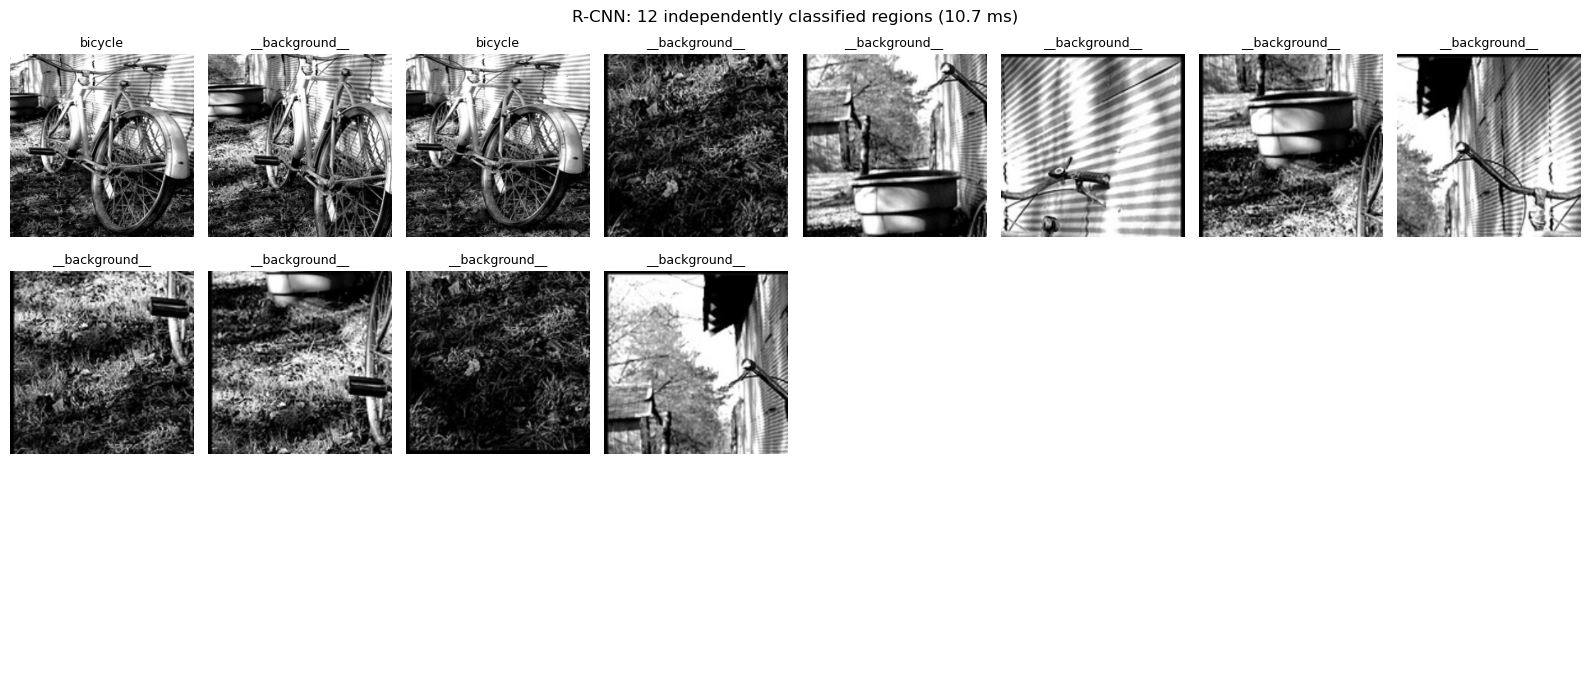

In [10]:
sample_image, sample_annotation = voc_validation[3]
sample_tensor, sample_boxes, _, _ = training_regions_from_voc(sample_image, sample_annotation)
sample_boxes = sample_boxes[:24]

# Keep raw crops for correct-color display and separate normalized copies for ResNet.
raw_crops, model_crops = [], []
for box in sample_boxes:
    x1, y1, x2, y2 = box.round().int().tolist()
    raw_crop = sample_tensor[:, y1:y2, x1:x2]
    raw_crop = resize(raw_crop, [224, 224], antialias=True)
    raw_crops.append(raw_crop)
    model_crops.append(PRETRAINED_WEIGHTS.transforms()(raw_crop))

# R-CNN still performs one logical backbone evaluation per region. A batch merely
# schedules those independent evaluations efficiently on the GPU.
rcnn.eval()
with torch.inference_mode():
    start = time.perf_counter()
    rcnn_logits = rcnn(torch.stack(model_crops).to(DEVICE))
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    rcnn_seconds = time.perf_counter() - start

figure, axes = plt.subplots(3, 8, figsize=(16, 7))
for axis in axes.flat:
    axis.axis("off")  # Hide unused axes so they do not appear as empty white boxes.
for axis, crop, prediction in zip(axes.flat, raw_crops, rcnn_logits.argmax(dim=1).cpu()):
    axis.imshow(crop.permute(1, 2, 0).clamp(0, 1))
    axis.set_title(VOC_CLASSES[prediction], fontsize=9)
figure.suptitle(f"R-CNN: {len(model_crops)} independently classified regions ({rcnn_seconds * 1000:.1f} ms)")
plt.tight_layout()
plt.show()


# Fast R-CNN: one image, one shared ResNet-18 feature map

Fast R-CNN uses the same VOC regions and labels as R-CNN, but performs convolution once per image. ROI Align samples each proposal from that shared map. The classifier learns VOC/background labels; the box head learns offsets from jittered proposals back to their matched VOC ground-truth boxes.


In [11]:
class FastRCNNResNet18(nn.Module):
    def __init__(self, rcnn_classifier=None):
        super().__init__()
        source = resnet18(weights=PRETRAINED_WEIGHTS)
        self.backbone = nn.Sequential(*list(source.children())[:-2])
        self.classifier = nn.Linear(512, len(VOC_CLASSES))
        self.box_regressor = nn.Linear(512, 4)

        # Start from the classifier R-CNN just learned; Fast R-CNN changes feature
        # sharing, not the meaning of the VOC classes.
        if rcnn_classifier is not None:
            self.classifier.load_state_dict(rcnn_classifier.state_dict())

    def forward(self, images, boxes_per_image):
        # One expensive convolutional pass produces a spatial map for the whole image.
        features = self.backbone(images)
        scale_y = features.shape[-2] / images.shape[-2]
        scale_x = features.shape[-1] / images.shape[-1]

        # ROI Align converts every variable-size proposal into a 7 × 7 feature grid.
        rois = roi_align(
            features, boxes_per_image, output_size=(7, 7),
            spatial_scale=(scale_x + scale_y) / 2, aligned=True,
        )
        pooled = rois.mean(dim=(-2, -1))
        return self.classifier(pooled), self.box_regressor(pooled), features, rois


fast_rcnn = FastRCNNResNet18(rcnn.fc).to(DEVICE)


In [12]:
def encode_box_deltas(proposals, matched_targets):
    """Encode a target box as center/size corrections relative to a proposal."""
    proposal_widths = (proposals[:, 2] - proposals[:, 0]).clamp(min=1)
    proposal_heights = (proposals[:, 3] - proposals[:, 1]).clamp(min=1)
    proposal_center_x = proposals[:, 0] + 0.5 * proposal_widths
    proposal_center_y = proposals[:, 1] + 0.5 * proposal_heights

    target_widths = (matched_targets[:, 2] - matched_targets[:, 0]).clamp(min=1)
    target_heights = (matched_targets[:, 3] - matched_targets[:, 1]).clamp(min=1)
    target_center_x = matched_targets[:, 0] + 0.5 * target_widths
    target_center_y = matched_targets[:, 1] + 0.5 * target_heights

    # Translation is normalized by proposal size; scale is represented in log space.
    return torch.stack([
        (target_center_x - proposal_center_x) / proposal_widths,
        (target_center_y - proposal_center_y) / proposal_heights,
        torch.log(target_widths / proposal_widths),
        torch.log(target_heights / proposal_heights),
    ], dim=1)


class FastRCNNImageDataset(Dataset):
    def __init__(self, voc_dataset, image_indices, regions_per_image=16):
        self.voc_dataset = voc_dataset
        self.image_indices = list(image_indices)
        self.regions_per_image = regions_per_image

    def __len__(self):
        return len(self.image_indices)

    def __getitem__(self, index):
        image, annotation = self.voc_dataset[self.image_indices[index]]
        image_tensor, boxes, labels, _ = training_regions_from_voc(image, annotation)
        boxes = boxes[:self.regions_per_image]
        labels = labels[:self.regions_per_image]

        # Match each region to the closest VOC object. Regression loss will later be
        # masked to positive labels, so background deltas are harmless placeholders.
        target_boxes, _ = unpack_target(annotation)
        matched_indices = box_iou(boxes, target_boxes).argmax(dim=1)
        box_deltas = encode_box_deltas(boxes, target_boxes[matched_indices])
        return image_tensor, boxes, labels, box_deltas


def fast_collate(batch):
    # Train one differently sized image at a time; keep boxes and labels unstacked.
    return batch[0]


fast_train = FastRCNNImageDataset(voc_train, range(FAST_RCNN_TRAIN_IMAGES))
fast_train_loader = DataLoader(fast_train, batch_size=1, shuffle=True, num_workers=4,
                               pin_memory=True, collate_fn=fast_collate)


In [13]:
# Fast R-CNN training also runs automatically during Run All.
FAST_RCNN_EPOCHS = 8
fast_optimizer = torch.optim.AdamW(fast_rcnn.parameters(), lr=2e-4, weight_decay=1e-4)
classification_loss = nn.CrossEntropyLoss()

for epoch in range(FAST_RCNN_EPOCHS):
    fast_rcnn.train()
    running_loss = 0.0
    for image, boxes, labels, target_deltas in fast_train_loader:
        # Resize the image uniformly and apply the identical scale to XYXY proposals.
        original_height, original_width = image.shape[-2:]
        resized_height = 672
        resized_width = round(original_width * resized_height / original_height)
        resized_image = resize(image, [resized_height, resized_width], antialias=True)
        box_scale = resized_height / original_height
        resized_boxes = boxes.to(DEVICE) * box_scale
        labels = labels.to(DEVICE)
        target_deltas = target_deltas.to(DEVICE)

        fast_optimizer.zero_grad()
        logits, predicted_deltas, _, _ = fast_rcnn(
            resized_image.unsqueeze(0).to(DEVICE), [resized_boxes]
        )
        classifier_loss = classification_loss(logits, labels)

        # Background has no object box to refine, so only positive regions contribute
        # to the smooth-L1 box-regression objective.
        positive = labels > 0
        box_loss = nn.functional.smooth_l1_loss(
            predicted_deltas[positive], target_deltas[positive], beta=1 / 9,
        ) if positive.any() else predicted_deltas.sum() * 0
        loss = classifier_loss + box_loss
        loss.backward()
        fast_optimizer.step()
        running_loss += loss.item()
    print(f"epoch {epoch + 1:02d}/{FAST_RCNN_EPOCHS} | Fast R-CNN joint loss {running_loss / len(fast_train_loader):.4f}")


epoch 01/8 | Fast R-CNN joint loss 1.6696
epoch 02/8 | Fast R-CNN joint loss 1.1128
epoch 03/8 | Fast R-CNN joint loss 0.8806
epoch 04/8 | Fast R-CNN joint loss 0.8104
epoch 05/8 | Fast R-CNN joint loss 0.5816
epoch 06/8 | Fast R-CNN joint loss 0.5412
epoch 07/8 | Fast R-CNN joint loss 0.4854
epoch 08/8 | Fast R-CNN joint loss 0.3318


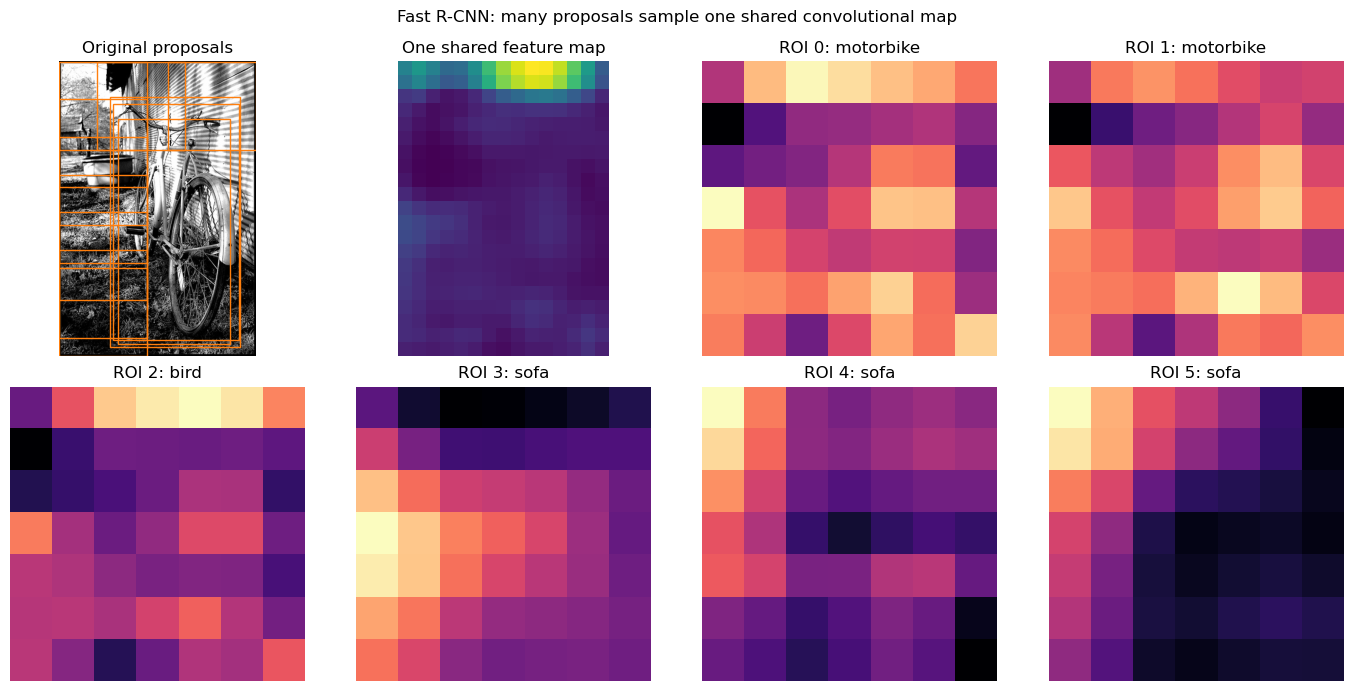

In [14]:
# Visualize correct-color proposals alongside the shared map and ROI features.
sample_image, sample_annotation = voc_validation[3]
sample_tensor, sample_boxes, _, _ = training_regions_from_voc(sample_image, sample_annotation)
sample_boxes = sample_boxes[:24]
original_height, original_width = sample_tensor.shape[-2:]
fast_image = resize(sample_tensor, [672, round(original_width * 672 / original_height)], antialias=True)
box_scale = fast_image.shape[-2] / original_height

fast_rcnn.eval()
with torch.inference_mode():
    fast_logits, fast_box_deltas, shared_features, roi_features = fast_rcnn(
        fast_image.unsqueeze(0).to(DEVICE), [sample_boxes.to(DEVICE) * box_scale]
    )

figure, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(sample_image)
for box in sample_boxes:
    x1, y1, x2, y2 = box.tolist()
    axes[0, 0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor="tab:orange", linewidth=1))
axes[0, 0].set_title("Original proposals")
axes[0, 1].imshow(shared_features[0].abs().mean(dim=0).cpu(), cmap="viridis")
axes[0, 1].set_title("One shared feature map")
for axis, roi_index in zip(axes.flat[2:], range(min(6, len(roi_features)))):
    axis.imshow(roi_features[roi_index].abs().mean(dim=0).cpu(), cmap="magma")
    axis.set_title(f"ROI {roi_index}: {VOC_CLASSES[fast_logits[roi_index].argmax()]}")
for axis in axes.flat:
    axis.axis("off")
figure.suptitle("Fast R-CNN: many proposals sample one shared convolutional map")
plt.tight_layout()
plt.show()


# Faster R-CNN: let the network propose regions (train last)

The final step removes hand-designed moving windows. A region proposal network slides over the shared ResNet-18 feature map and learns objectness plus box offsets. The ROI head then classifies and refines those learned proposals. This custom torchvision model keeps the **same ImageNet-pretrained ResNet-18 backbone** used in every earlier section.

The training cell is opt-in and intentionally last. Nothing after it is required for the Lecture 16 walkthrough.


In [15]:
class VOCObjectDetectionDataset(Dataset):
    def __init__(self, voc_dataset, image_indices):
        self.voc_dataset = voc_dataset
        self.image_indices = list(image_indices)

    def __len__(self):
        return len(self.image_indices)

    def __getitem__(self, index):
        image_index = self.image_indices[index]
        image, annotation = self.voc_dataset[image_index]
        boxes, labels = unpack_target(annotation)

        # torchvision detectors accept unnormalized CHW float images in [0, 1].
        image = pil_to_tensor(image).float() / 255
        target = {
            "boxes": boxes,              # VOC ground-truth XYXY boxes
            "labels": labels,            # VOC ground-truth class indices
            "image_id": torch.tensor(image_index),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros(len(boxes), dtype=torch.int64),
        }
        return image, target


def detection_collate(batch):
    # Images and annotation counts vary, so return lists rather than stacking tensors.
    return tuple(zip(*batch))


detection_train = VOCObjectDetectionDataset(voc_train, range(FASTER_RCNN_TRAIN_IMAGES))
detection_validation = VOCObjectDetectionDataset(voc_validation, range(100))
detection_train_loader = DataLoader(
    detection_train, batch_size=4, shuffle=True, num_workers=4,
    pin_memory=True, collate_fn=detection_collate,
)


In [16]:
def make_faster_rcnn_resnet18():
    # Reuse the same ImageNet-pretrained ResNet-18 convolutional body again.
    source = resnet18(weights=PRETRAINED_WEIGHTS)
    backbone = nn.Sequential(*list(source.children())[:-2])
    backbone.out_channels = 512  # required so torchvision can size the RPN/ROI heads

    # At every feature location, test five object scales and three aspect ratios.
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),),
    )

    # A single ResNet map is exposed under key "0" by FasterRCNN's wrapper.
    roi_pooler = MultiScaleRoIAlign(featmap_names=["0"], output_size=7, sampling_ratio=2)
    return FasterRCNN(
        backbone,
        num_classes=len(VOC_CLASSES),
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=600,
        max_size=1000,
    )


faster_rcnn = make_faster_rcnn_resnet18().to(DEVICE)
trainable = sum(parameter.numel() for parameter in faster_rcnn.parameters() if parameter.requires_grad)
print(f"Faster R-CNN trainable parameters: {trainable:,}")


Faster R-CNN trainable parameters: 40,423,156


In [17]:
# The final detector trains automatically when this cell is reached.
FASTER_RCNN_EPOCHS = 8
detector_optimizer = torch.optim.SGD(
    [parameter for parameter in faster_rcnn.parameters() if parameter.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=5e-4,
)
detector_scheduler = torch.optim.lr_scheduler.StepLR(detector_optimizer, step_size=5, gamma=0.1)

for epoch in range(FASTER_RCNN_EPOCHS):
    faster_rcnn.train()
    running_loss = 0.0
    loss_totals = {}
    for images, targets in detection_train_loader:
        images = [image.to(DEVICE, non_blocking=True) for image in images]
        targets = [
            {key: value.to(DEVICE, non_blocking=True) for key, value in target.items()}
            for target in targets
        ]

        detector_optimizer.zero_grad()
        # Train mode returns RPN objectness/regression and ROI classification/regression losses.
        losses = faster_rcnn(images, targets)
        loss = sum(losses.values())
        loss.backward()
        detector_optimizer.step()

        running_loss += loss.item()
        for name, value in losses.items():
            loss_totals[name] = loss_totals.get(name, 0.0) + value.item()

    detector_scheduler.step()
    details = " | ".join(
        f"{name.replace('loss_', '')} {total / len(detection_train_loader):.3f}"
        for name, total in loss_totals.items()
    )
    print(f"epoch {epoch + 1:02d}/{FASTER_RCNN_EPOCHS} | total {running_loss / len(detection_train_loader):.4f} | {details}")


epoch 01/8 | total 0.6490 | classifier 0.316 | box_reg 0.151 | objectness 0.152 | rpn_box_reg 0.030
epoch 02/8 | total 0.5271 | classifier 0.240 | box_reg 0.168 | objectness 0.093 | rpn_box_reg 0.026
epoch 03/8 | total 0.5037 | classifier 0.225 | box_reg 0.178 | objectness 0.076 | rpn_box_reg 0.025
epoch 04/8 | total 0.4759 | classifier 0.206 | box_reg 0.182 | objectness 0.064 | rpn_box_reg 0.024
epoch 05/8 | total 0.4348 | classifier 0.181 | box_reg 0.178 | objectness 0.054 | rpn_box_reg 0.022
epoch 06/8 | total 0.3970 | classifier 0.161 | box_reg 0.176 | objectness 0.044 | rpn_box_reg 0.016
epoch 07/8 | total 0.3884 | classifier 0.156 | box_reg 0.175 | objectness 0.042 | rpn_box_reg 0.016
epoch 08/8 | total 0.3803 | classifier 0.152 | box_reg 0.173 | objectness 0.040 | rpn_box_reg 0.015


## Faster R-CNN examples after training

Each panel overlays the model’s post-NMS predictions in bright colors and the Pascal VOC ground truth as dashed white boxes. The score slider makes the precision/recall tradeoff visible. These cells come after training, so **Run All** displays the newly trained model rather than an untrained detector.


In [18]:
@torch.inference_mode()
def predict_faster_rcnn(index):
    image, target = detection_validation[index]
    faster_rcnn.eval()
    prediction = faster_rcnn([image.to(DEVICE)])[0]
    return image, target, {key: value.cpu() for key, value in prediction.items()}


def show_faster_rcnn_examples(start_index=0, score_threshold=0.50):
    figure, axes = plt.subplots(2, 3, figsize=(18, 12))
    for axis, index in zip(axes.flat, range(start_index, start_index + 6)):
        image, target, prediction = predict_faster_rcnn(index)
        keep = prediction["scores"] >= score_threshold

        axis.imshow(image.permute(1, 2, 0).clamp(0, 1))

        # Dashed white rectangles are the human-authored Pascal VOC annotations.
        for box, label in zip(target["boxes"], target["labels"]):
            x1, y1, x2, y2 = box.tolist()
            axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     fill=False, edgecolor="white", linewidth=2,
                                     linestyle="--"))
            axis.text(x1, y2, f"GT: {VOC_CLASSES[label]}", color="black", fontsize=8,
                      bbox={"facecolor": "white", "alpha": 0.8, "pad": 1})

        # Solid colored rectangles are learned Faster R-CNN predictions after its NMS.
        for box, label, score in zip(
            prediction["boxes"][keep], prediction["labels"][keep], prediction["scores"][keep]
        ):
            x1, y1, x2, y2 = box.tolist()
            axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     fill=False, edgecolor="lime", linewidth=2))
            axis.text(x1, y1, f"{VOC_CLASSES[label]} {score:.2f}", color="black", fontsize=8,
                      bbox={"facecolor": "lime", "alpha": 0.8, "pad": 1})

        axis.set_title(f"VOC validation image {index}: {keep.sum().item()} predictions")
        axis.axis("off")
    plt.tight_layout()
    plt.show()


interact(
    show_faster_rcnn_examples,
    start_index=IntSlider(min=0, max=90, step=6, value=0, continuous_update=False),
    score_threshold=FloatSlider(min=0.1, max=0.95, step=0.05, value=0.50, continuous_update=False),
);


interactive(children=(IntSlider(value=0, continuous_update=False, description='start_index', max=90, step=6), …

# Lecture 16 takeaway

The pretrained ResNet-18 never changed its fundamental job: turn pixels into useful visual features. What evolved was **where proposals come from** and **how often the backbone runs**.

| detector | proposals | backbone work | learned box refinement |
|---|---|---:|---:|
| classic | pyramid + moving window | once per window | no |
| R-CNN | external regions | once per region | optional/separate |
| Fast R-CNN | external regions | once per image | yes |
| Faster R-CNN | learned RPN | once per image | yes |
